In [188]:

import dagshub
dagshub.init(repo_owner='tshub23', repo_name='proj1', mlflow=True)

Initialized MLflow to track repo "tshub23/proj1"

Repository tshub23/proj1 initialized!

In [189]:
import pandas as pd


train_df = pd.read_csv("/home/tornike/ML/proj1/train.csv")
test_df = pd.read_csv("/home/tornike/ML/proj1/test.csv")
test_ids = test_df["Id"]

train_df.head()



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [190]:
# Feature engineering
import numpy as np


X = train_df.drop(columns=["SalePrice"])
y = np.log1p(train_df["SalePrice"])



# Data Cleaning

In [191]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error
import numpy as np


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



# NA precentage

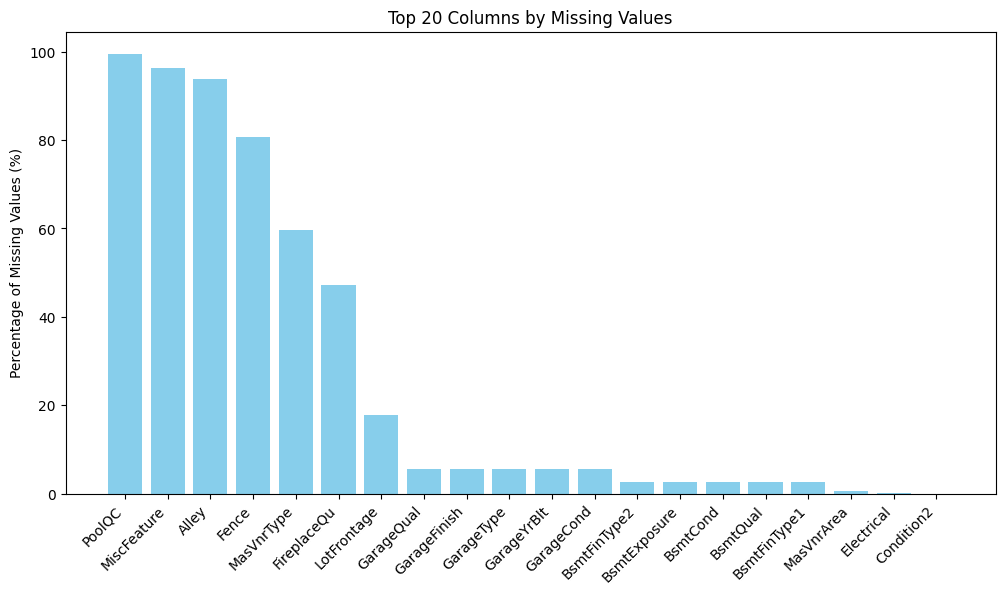

In [192]:
na_percent = (train_df.isnull().sum() / len(train_df)) * 100
na_percent = na_percent.sort_values(ascending=False)


import matplotlib.pyplot as plt


top_na = na_percent.head(20)

plt.figure(figsize=(12,6))
plt.bar(top_na.index, top_na.values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Percentage of Missing Values (%)")
plt.title("Top 20 Columns by Missing Values")
plt.show()



# drop many NA columns

In [193]:
high_na_cols = na_percent[na_percent >= 40].index

X_train = X_train.drop(columns=high_na_cols)
X_val = X_val.drop(columns=high_na_cols)

test_df = test_df.drop(columns=high_na_cols)

In [194]:
print("Dropped columns:", list(high_na_cols))
print("Remaining columns:", X_train.shape[1])

Dropped columns: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
Remaining columns: 74


In [195]:

categorical_cols = X_train.select_dtypes(include=['object']).columns
print("Categorical columns now:", list(categorical_cols))


for col in categorical_cols:
    
    codes, uniques = pd.factorize(X_train[col].dropna())
    
    
    mapping = dict(zip(uniques, range(len(uniques))))
    
    
    X_train[col] = X_train[col].map(mapping)
    X_val[col]   = X_val[col].map(mapping)
    test_df[col] = test_df[col].map(mapping)

Categorical columns now: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [196]:
test_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,3.0,80.0,11622,0,0,0,0.0,0,...,0,0,0,120,0,0,6,2010,0.0,0
1,1462,20,0.0,81.0,14267,0,1,0,0.0,1,...,36,0,0,0,0,12500,6,2010,0.0,0
2,1463,60,0.0,74.0,13830,0,1,0,0.0,0,...,34,0,0,0,0,0,3,2010,0.0,0
3,1464,60,0.0,78.0,9978,0,1,0,0.0,0,...,36,0,0,0,0,0,6,2010,0.0,0
4,1465,120,0.0,43.0,5005,0,1,2,0.0,0,...,82,0,0,144,0,0,1,2010,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,1.0,21.0,1936,0,0,0,0.0,0,...,0,0,0,0,0,0,6,2006,0.0,0
1455,2916,160,1.0,21.0,1894,0,0,0,0.0,0,...,24,0,0,0,0,0,4,2006,0.0,1
1456,2917,20,0.0,160.0,20000,0,0,0,0.0,0,...,0,0,0,0,0,0,9,2006,0.0,1
1457,2918,85,0.0,62.0,10441,0,0,0,0.0,0,...,32,0,0,0,0,700,7,2006,0.0,0


In [197]:
X_train.isnull().sum().sort_values(ascending=False).head(20)


LotFrontage     217
GarageCond       64
GarageQual       64
GarageType       64
GarageYrBlt      64
GarageFinish     64
BsmtFinType1     28
BsmtQual         28
BsmtExposure     28
BsmtCond         28
BsmtFinType2     28
MasVnrArea        6
Electrical        1
LotConfig         0
Street            0
LotArea           0
MSZoning          0
MSSubClass        0
Id                0
Utilities         0
dtype: int64

In [198]:

numeric_cols_with_na = ["LotFrontage", "GarageYrBlt", "MasVnrArea"]

for col in numeric_cols_with_na:
    
    median = X_train[col].median()
    
    X_train[col] = X_train[col].fillna(median)
    X_val[col]   = X_val[col].fillna(median)
    test_df[col] = test_df[col].fillna(median)
    

In [199]:
# Identify skewed numeric features
numeric_feats = X_train.select_dtypes(include=[np.number]).columns
skewed_feats = X_train[numeric_feats].skew().sort_values(ascending=False)
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75].index

# Log-transform skewed features
for feat in skewed_feats:
    X_train[feat] = np.log1p(X_train[feat])
    X_val[feat]   = np.log1p(X_val[feat])
    test_df[feat] = np.log1p(test_df[feat])

In [200]:
def drop_high_correlation_features(X_train, X_val, test_df, threshold=0.9):
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"Dropping {len(to_drop)} columns due to correlation > {threshold}: {to_drop}")
    X_train_filtered = X_train.drop(columns=to_drop)
    X_val_filtered   = X_val.drop(columns=to_drop)
    test_df_filtered = test_df.drop(columns=to_drop)
    return X_train_filtered, X_val_filtered, test_df_filtered

X_train, X_val, test_df = drop_high_correlation_features(X_train, X_val, test_df, threshold=0.8)

Dropping 4 columns due to correlation > 0.8: ['Exterior2nd', 'BsmtFinSF2', 'TotRmsAbvGrd', 'GarageArea']


In [201]:

quality_mapping = {"Ex":5, "Gd":4, "TA":3, "Fa":2, "Po":1}

for col in ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "KitchenQual", "GarageQual", "GarageCond"]:
    X_train[col] = X_train[col].map(quality_mapping)
    X_val[col]   = X_val[col].map(quality_mapping)
    test_df[col] = test_df[col].map(quality_mapping)


for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].fillna("None")
    X_val[col]   = X_val[col].fillna("None")
    test_df[col] = test_df[col].fillna("None")

# One-hot encode nominal categoricals
X_train = pd.get_dummies(X_train)
X_val   = pd.get_dummies(X_val)
test_df = pd.get_dummies(test_df)

# Align columns
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, test_df = X_train.align(test_df, join='left', axis=1, fill_value=0)

In [202]:
X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,3.044522,0.0,4.262680,9.036106,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,6,2010,0.0,0.0
1066,1067,4.110874,0.0,4.094345,8.966739,0.0,0.693147,0.0,0.0,0.000000,...,3.713572,0.000000,0.0,0.0,0.0,0.0,5,2009,0.0,0.0
638,639,3.433987,0.0,4.219508,9.080004,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,5.105945,0.0,0.0,0.0,0.0,5,2008,0.0,0.0
799,800,3.931826,0.0,4.110874,8.881975,0.0,0.000000,0.0,0.0,0.693147,...,0.000000,5.579730,0.0,0.0,0.0,0.0,6,2007,0.0,0.0
380,381,3.931826,0.0,3.931826,8.517393,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,5.493061,0.0,0.0,0.0,0.0,5,2010,0.0,0.0


In [203]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np


model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=50)

preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, preds))
print("XGBoost RMSE:", rmse)




test_preds = np.expm1(model.predict(test_df))

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_preds
})
submission.to_csv("submission.csv", index=False)

X_train.head()


[0]	validation_0-rmse:0.41731
[50]	validation_0-rmse:0.15548
[100]	validation_0-rmse:0.13645
[150]	validation_0-rmse:0.13223
[200]	validation_0-rmse:0.13170
[250]	validation_0-rmse:0.13169
[300]	validation_0-rmse:0.13164
[350]	validation_0-rmse:0.13154
[400]	validation_0-rmse:0.13157
[450]	validation_0-rmse:0.13164
[500]	validation_0-rmse:0.13157
[550]	validation_0-rmse:0.13157
[600]	validation_0-rmse:0.13159
[650]	validation_0-rmse:0.13161
[700]	validation_0-rmse:0.13158
[750]	validation_0-rmse:0.13161
[800]	validation_0-rmse:0.13169
[850]	validation_0-rmse:0.13166
[900]	validation_0-rmse:0.13170
[950]	validation_0-rmse:0.13170
[999]	validation_0-rmse:0.13171
XGBoost RMSE: 0.13170670427063588


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,3.044522,0.0,4.262680,9.036106,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,6,2010,0.0,0.0
1066,1067,4.110874,0.0,4.094345,8.966739,0.0,0.693147,0.0,0.0,0.000000,...,3.713572,0.000000,0.0,0.0,0.0,0.0,5,2009,0.0,0.0
638,639,3.433987,0.0,4.219508,9.080004,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,5.105945,0.0,0.0,0.0,0.0,5,2008,0.0,0.0
799,800,3.931826,0.0,4.110874,8.881975,0.0,0.000000,0.0,0.0,0.693147,...,0.000000,5.579730,0.0,0.0,0.0,0.0,6,2007,0.0,0.0
380,381,3.931826,0.0,3.931826,8.517393,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,5.493061,0.0,0.0,0.0,0.0,5,2010,0.0,0.0


In [204]:
with mlflow.start_run(run_name="removed rfe with 21 features"):
    
    import xgboost as xgb
    from sklearn.metrics import mean_squared_error
    import numpy as np

    model = xgb.XGBRegressor(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )

    model.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=50)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    print("RMSE with XGBoost:", rmse)
    mlflow.log_metric("rmse", rmse)
    mlflow.sklearn.log_model(
        model,
        artifact_path="model",
        registered_model_name="XGModel"
    )
   
    test_preds = np.expm1(model.predict(test_df))

    submission = pd.DataFrame({
        "Id": test_ids,
        "SalePrice": test_preds
    })
    submission.to_csv("submission.csv", index=False)
    
    


[0]	validation_0-rmse:0.41728
[50]	validation_0-rmse:0.15483
[100]	validation_0-rmse:0.13768
[150]	validation_0-rmse:0.13410
[200]	validation_0-rmse:0.13352
[250]	validation_0-rmse:0.13341
[300]	validation_0-rmse:0.13318
[350]	validation_0-rmse:0.13308
[400]	validation_0-rmse:0.13292
[450]	validation_0-rmse:0.13267
[500]	validation_0-rmse:0.13272
[550]	validation_0-rmse:0.13265
[600]	validation_0-rmse:0.13253
[650]	validation_0-rmse:0.13251
[700]	validation_0-rmse:0.13248
[750]	validation_0-rmse:0.13246
[800]	validation_0-rmse:0.13246
[850]	validation_0-rmse:0.13246
[900]	validation_0-rmse:0.13251
[950]	validation_0-rmse:0.13251
[999]	validation_0-rmse:0.13252
RMSE with XGBoost: 0.1325207260590452


2026/04/13 17:52:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:52:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run removed rfe with 21 features at: https://dagshub.com/tshub23/proj1.mlflow/#/experiments/0/runs/cebb806e7f6b4a74a897499e278f5f13
🧪 View experiment at: https://dagshub.com/tshub23/proj1.mlflow/#/experiments/0


Registered model 'BestModelXg' already exists. Creating a new version of this model...


MlflowException: Unable to find a logged_model with artifact_path model under run cebb806e7f6b4a74a897499e278f5f13